In [1]:
library(devtools)
library(data.table)
library(ggplot2)
library(ggrastr)
setwd('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/')

Loading required package: usethis



In [2]:
devtools::load_all('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/ukbtools')

i Loading ukbtools

Loading required package: tidyverse

-- Attaching packages ----------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse 1.3.1 --

v tibble  3.1.5     v dplyr   1.0.7
v tidyr   1.1.4     v stringr 1.4.0
v readr   1.4.0     v forcats 0.5.1
v purrr   0.3.4     

-- Conflicts -------------------------------------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::between()   masks data.table::between()
x dplyr::filter()    masks stats::filter()
x dplyr::first()     masks data.table::first()
x dplyr::lag()       masks stats::lag()
x dplyr::last()      masks data.table::last()
x purrr::transpose() masks data.table::transpose()

! Adding files missing in collate: /gpfs3/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/ukbtools/R/extract_field_by_gene_sample

In [3]:
# For each phenotype assocation
# * how many compound hetz knockouts
# * how many homozygous knockouts
# * how many completely PTV knockouts
# * how many completely missense knockouts
# * how many mixed knockouts

In [4]:
# knockout counts
knockouts <- list.files('derived/knockouts/211111/', full.names = TRUE)

# phenotypes
pheno_binary <- unlist(strsplit(readLines('data/phenotypes/UKBB_WES200k_binary_phenotypes_header.txt'), split = '\t'))
pheno_cts <- unlist(strsplit(readLines('data/phenotypes/UKBB_WES200k_cts_phenotypes_header.txt'), split = '\t'))

# saige results
saige_binary <- list.files('data/saige/output/combined/binary/step2/211111/', full.names = TRUE)

# thresholds
mutations <- c('ptv','ptv_damaging_missense','synonymous')
mafs <- c('00_01','01_50','00_50')

In [97]:
load_saige_bundle <- function(files, maf, mutation,pheno){
    
    # set thresholds
    #maf = '00_01'
    #pheno = "Cirrhosis"
    #mutation = 'ptv_damaging_missense'

    # subset files
    pheno_mutation = paste0(mutation,'_',pheno)
    bool_maf = grepl(maf, saige_binary)
    bool_pheno = grepl(pheno, saige_binary)
    bool_mutation = grepl(pheno_mutation, saige_binary)

    # load files
    files <- saige_binary[bool_pheno & bool_mutation & bool_maf]
    stopifnot(length(files) > 0)
    combined <- setDT(do.call(rbind, lapply(files, fread)))
    
    # add analytical uniform expecation
    n <- nrow(combined)
    combined <- combined[order(combined$p.value),]
    combined$pvalue.observed <- combined$p.value
    combined$pvalue.expected <- seq(1, n)/(n + 1)
    
    # clean up
    colnames(combined)[colnames(combined)=='SNPID'] <- 'gene_id'
    
    return(combined)
    
}

load_knockout_bundle <- function(files, maf, mutation){
    
    # subset to files
    bool_maf = grepl(maf, files)
    mutation_file = paste0(mutation,'_','knockouts')
    bool_mutation = grepl(mutation_file, files)

    # load files
    files <- files[bool_mutation & bool_maf]
    stopifnot(length(files) > 0)
    combined <- setDT(do.call(rbind, lapply(files, zcat)))
 
    # aggregate knockouts type by gene id
    dt <- data.table(table(combined$gene_id, combined$csqs))
    dt <- data.table::dcast(dt, V1 ~ V2, value.var = 'N')
    colnames(dt)[1] <- 'gene_id'
    
    # clean up outout
    if ('CH+HO' %in% colnames(dt)){
        dt$HO <- dt$HO + dt$`CH+HO`
        dt$`CH+HO` <- NULL
    }

    return(dt)
}

get_knockout_sample_counts <- function(files, maf, mutation){
    
    # subset to files
    bool_maf = grepl(maf, files)
    mutation_file = paste0(mutation,'_','knockouts')
    bool_mutation = grepl(mutation_file, files)

    # load files
    files <- files[bool_mutation & bool_maf]
    stopifnot(length(files) > 0)
    combined <- setDT(do.call(rbind, lapply(files, zcat)))
    combined$csqs[combined$csqs %in% c('CH+HO','HO+CH')] <- 'HO'
    
    # combine haplotypes on string
    combined <- combined[combined$csqs %in% c('CH','HO')]
    combined$phase1 <- format_from_hail(combined$phase1)
    combined$phase2 <- format_from_hail(combined$phase2)
    combined$haplotypes <- apply(combined[,c('phase1','phase2')], 1, paste, collapse = '|')
    
    dt_ho <- combined[combined$csqs %in% c('HO')]
    dt_ch <- combined[combined$csqs %in% c('CH')]
    
    # deal with homozygous
    table_ho <- as.data.table(table(dt_ho$gene_id, dt_ho$haplotypes))
    table_ho <- table_ho[table_ho$N > 0]
    table_ho$csqs <- 'homozygous'

    # deal with compound hetz
    table_ch <- as.data.table(table(dt_ho$gene_id, dt_ho$haplotypes))
    table_ch <- table_ch[table_ch$N > 0]
    table_ch$csqs <- 'compound heterozygous'

    # combine and re-name
    table_ch_ho <- rbind(table_ho, table_ch)
    colnames(table_ch_ho) <- c('ensgid','haplotypes','sample count','csqs')

    # add chromosome and re-roder
    table_ch_ho$chr <- unlist(lapply(strsplit(table_ch_ho$haplotypes, split = '_'), function(x) gsub('chr','',x[1])))
    table_ch_ho <- table_ch_ho[order(table_ch_ho$chr),]
    return(table_ch_ho)
    
}


In [7]:
maf = '01_50'
pheno = 'Cirrhosis'
mutation = 'ptv_damaging_missense'
kos <- load_knockout_bundle(knockouts, maf, mutation)

In [8]:
maf = '01_50'
pheno = 'Cirrhosis'
mutation = 'ptv_damaging_missense'

dts <- load_saige_bundle(saige_binary, maf, mutation, pheno)
kos <- load_knockout_bundle(knockouts, maf, mutation)
mrg <- merge(dts, kos, by = 'gene_id', all.x = TRUE)

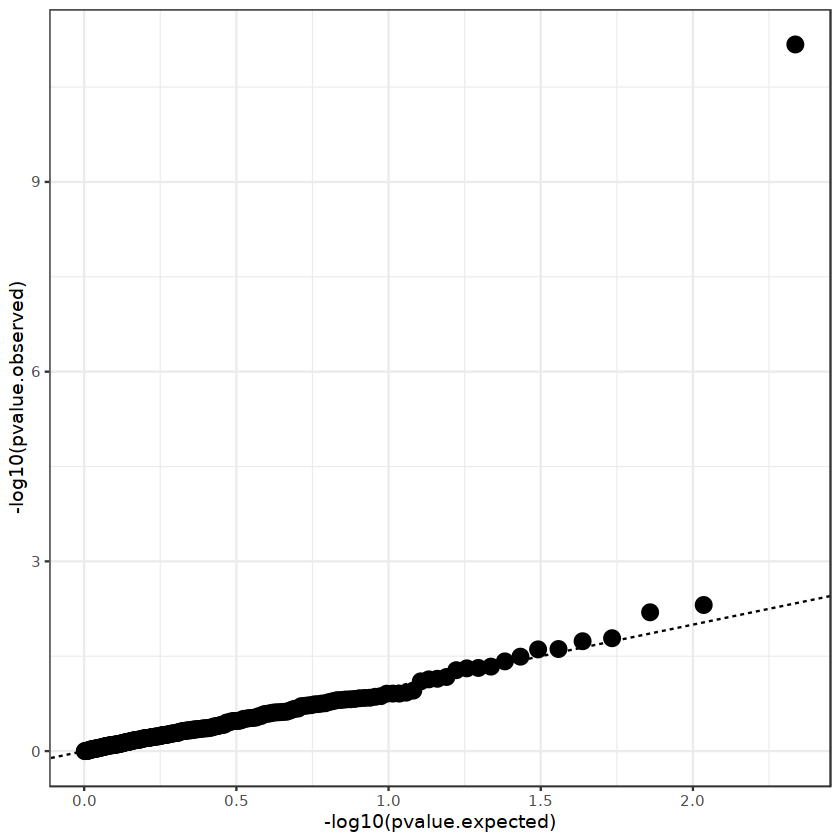

In [7]:
ggplot(mrg, aes(x=-log10(pvalue.expected), y = -log10(pvalue.observed))) +
    geom_point(size = 4) +
    geom_abline(linetype = 'dashed') + 
    theme_bw()

[1] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_damaging_missense_knockouts.tsv.bgz"       
   [2] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_damaging_missense_ko.vcf.bgz"              
   [3] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_damaging_missense_ko.vcf.bgz.csi"          
   [4] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_damaging_missense_ko_prob.tsv.bgz"         
   [5] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_knockouts.tsv.bgz"                         
   [6] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ko.vcf.bgz"                                
   [7] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ko.vcf.bgz.csi"                            
   [8] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ko_prob.tsv.bgz"                           
   [9] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_damaging_missense_knockouts.tsv.bgz"
  [10] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_damaging_missense_ko.vcf.bgz"       
  [11] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_damaging_missense_ko.vcf.bgz.csi"   
  [12] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_damaging_missense_ko_prob.tsv.bgz"  
  [13] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_knockouts.tsv.bgz"                  
  [14] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_ko.vcf.bgz"                         
  [15] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_ko.vcf.bgz.csi"                     
  [16] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_ptv_ptv_LC_ko_prob.tsv.bgz"                    
  [17] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_synonymous_knockouts.tsv.bgz"                  
  [18] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_synonymous_ko.vcf.bgz"                         
  [19] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_synonymous_ko.vcf.bgz.csi"                     
  [20] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr10_synonymous_ko_prob.tsv.bgz"                    
  [21] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_damaging_missense_knockouts.tsv.bgz"       
  [22] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_damaging_missense_ko.vcf.bgz"              
  [23] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_damaging_missense_ko.vcf.bgz.csi"          
  [24] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_damaging_missense_ko_prob.tsv.bgz"         
  [25] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_knockouts.tsv.bgz"                         
  [26] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ko.vcf.bgz"                                
  [27] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ko.vcf.bgz.csi"                            
  [28] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ko_prob.tsv.bgz"                           
  [29] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_damaging_missense_knockouts.tsv.bgz"
  [30] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_damaging_missense_ko.vcf.bgz"       
  [31] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_damaging_missense_ko.vcf.bgz.csi"   
  [32] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_damaging_missense_ko_prob.tsv.bgz"  
  [33] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_knockouts.tsv.bgz"                  
  [34] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_ko.vcf.bgz"                         
  [35] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_ko.vcf.bgz.csi"                     
  [36] "derived/knockouts/211111//ukb_wes_200k_maf00_01_chr11_ptv_ptv_LC_ko_prob.tsv.bgz"                    
  [37] "derived/knockouts/211111//ukb_wes_2

In [98]:
get_knockout_sample_counts(knockouts, '00_01','ptv')

ensgid,haplotypes,sample count,csqs,chr
<chr>,<chr>,<int>,<chr>,<chr>
ENSG00000168765,chr1_109657672_G_A|chr1_109657672_G_A,1,homozygous,1
ENSG00000009724,chr1_11046735_T_C|chr1_11046735_T_C,1,homozygous,1
ENSG00000162571,chr1_1180842_C_CG|chr1_1180842_C_CG,3,homozygous,1
ENSG00000116731,"chr1_13778643_ATG_A,chr1_13778646_AT_A|chr1_13778643_ATG_A,chr1_13778646_AT_A",1,homozygous,1
ENSG00000256374,chr1_145241638_G_A|chr1_145241638_G_A,7,homozygous,1
ENSG00000188092,chr1_147943538_C_T|chr1_147943538_C_T,1,homozygous,1
ENSG00000150337,chr1_149784224_C_T|chr1_149784224_C_T,6,homozygous,1
ENSG00000014914,chr1_149936633_G_GC|chr1_149936633_G_GC,5,homozygous,1
ENSG00000143369,chr1_150511825_G_A|chr1_150511825_G_A,1,homozygous,1


In [102]:
colnames(dt01_50)[2:5]

[1] "CH" "HE" "HO" NA

In [114]:
length(knockouts)

[1] 1315

In [129]:
files <- knockouts

dt00_01 <- load_knockout_bundle(files, '00_01','ptv')
colnames(dt00_01)[2:4] <- paste0('00_01.',colnames(dt00_01)[2:4])
dt01_50 <- load_knockout_bundle(files, '01_50','ptv')
colnames(dt01_50)[2:4] <- paste0('01_50.',colnames(dt01_50)[2:4])
dt00_50 <- load_knockout_bundle(files, '00_50','ptv')
colnames(dt00_50)[2:4] <- paste0('00_50.',colnames(dt00_50)[2:4])
mrg <- merge(merge(dt00_01, dt01_50), dt00_50)


[1] 0

In [ ]:
merge(dt00_01, dt01_50, )

In [9]:
for (phenotype in c('Cirrhosis')){
    outlist <- list()
    for (maf in c('01_50')){
        for (mutation in mutations){
            print(mutation)
            id <- paste0(pheno,maf,mutation, sep = '_')
            print(id)
            dts <- load_saige_bundle(saige_binary, maf, mutation, pheno)
            kos <- load_knockout_bundle(knockouts, maf, mutation)
            mrg <- merge(dts, kos, by = 'gene_id', all.x = TRUE)
            mrg$phenotype <- phenotype
            mrg$maf <- maf 
            mrg$mutation <- mutation
            outlist[[id]] <- mrg
        }
    }     
    combined <- as.data.table(do.call(rbind, outlist))
}


    

In [ ]:
ggplot(combined, aes(x=-log10(pvalue.expected), y = -log10(pvalue.observed), color = mutation)) +
    geom_point(size = 4) +
    geom_abline(linetype = 'dashed') + 
    theme_bw() +
    facet_wrap(mutation ~ maf)

In [12]:

maf = '00_50'
mutation = 'ptv'
files = knockouts
# subset to files
    bool_maf = grepl(maf, files)
    mutation_file = paste0(mutation,'_','knockouts')
    bool_mutation = grepl(mutation_file, files)

    # load files
    files <- files[bool_mutation & bool_maf]
    stopifnot(length(files) > 0)
    combined <- setDT(do.call(rbind, lapply(files, zcat)))
 
    # aggregate by gene id
    dt <- data.table(table(combined$gene_id, combined$csqs))
    dt <- data.table::dcast(dt, V1 ~ V2, value.var = 'N')
    colnames(dt)[1] <- 'gene_id'



In [20]:
combined <- head(combined[combined$csqs == 'CH'])
x <- combined

In [21]:
na_collapse <- function(x) paste0(na.omit(x), collapse = ';')
rsids_combined <- apply(x[,c('phase1','phase2')], 1, na_collapse)
rsids_combined <- gsub('(\\[)|(\\])|(\\")', '', rsids_combined)

In [22]:
rsids_combined

[1] "chr10_104275224_A_G;chr10_104299178_G_A"     
[2] "chr10_50097803_G_A;chr10_50068169_G_A"       
[3] "chr10_50097803_G_A;chr10_50068169_G_A"       
[4] "chr10_50068169_G_A;chr10_50097803_G_A"       
[5] "chr10_16940152_G_A;chr10_16836383_C_T"       
[6] "chr10_17068706_G_C;chr10_16918687_ATAACCTC_A"

In [59]:
dt <- load_knockout_bundle(knockouts, '00_01','ptv')

In [60]:
# translate genes into hgnc_symbol
hgnc_bridge <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/hgnc/211026_hgnc_ensgid_link.csv')
colnames(hgnc_bridge)[2] <- 'gene_id'
dt <- merge(dt, hgnc_bridge, by = 'gene_id', all.x = TRUE)

In [61]:
# Load LOEUF deciles
constraints <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv')
constraints$loeuf <- constraints$oe_lof_upper 
constraints <- constraints[constraints$canonical == TRUE,]

# create deciles
deciles_loeuf_seq <- seq(0,1,by = 0.1)
deciles_loeuf <- quantile(constraints$loeuf, probs = deciles_loeuf_seq, na.rm = T)
constraints$decile <- cut(constraints$loeuf, deciles_loeuf)
levels(constraints$decile) <- deciles_loeuf_seq*100
constraints$decile_plot <-  paste0(constraints$decile,'-', as.numeric(as.character(constraints$decile))+10)
constraints$decile_plot[constraints$decile_plot == 'NA-NA'] <- NA

In [62]:
colnames(constraints)[1] <- 'hgnc_symbol'
combined <- merge(dt, constraints[,c('hgnc_symbol','decile_plot')], by = 'hgnc_symbol')
combined <- combined[combined$CH > 0 | combined$HO > 0]
melted <- melt(combined)

Warning message in melt.data.table(combined):
"id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns [hgnc_symbol, gene_id, decile_plot, ...]. Consider providing at least one of 'id' or 'measure' vars in future."


In [33]:
head(melted)

hgnc_symbol,gene_id,decile_plot,variable,value
<chr>,<chr>,<chr>,<fct>,<int>
A2ML1,ENSG00000166535,50-60,CH,1
AARD,ENSG00000205002,60-70,CH,0
ABCA13,ENSG00000179869,50-60,CH,4
ABCA7,ENSG00000064687,50-60,CH,7
ABCA8,ENSG00000141338,60-70,CH,1
ABCA9,ENSG00000154258,50-60,CH,2


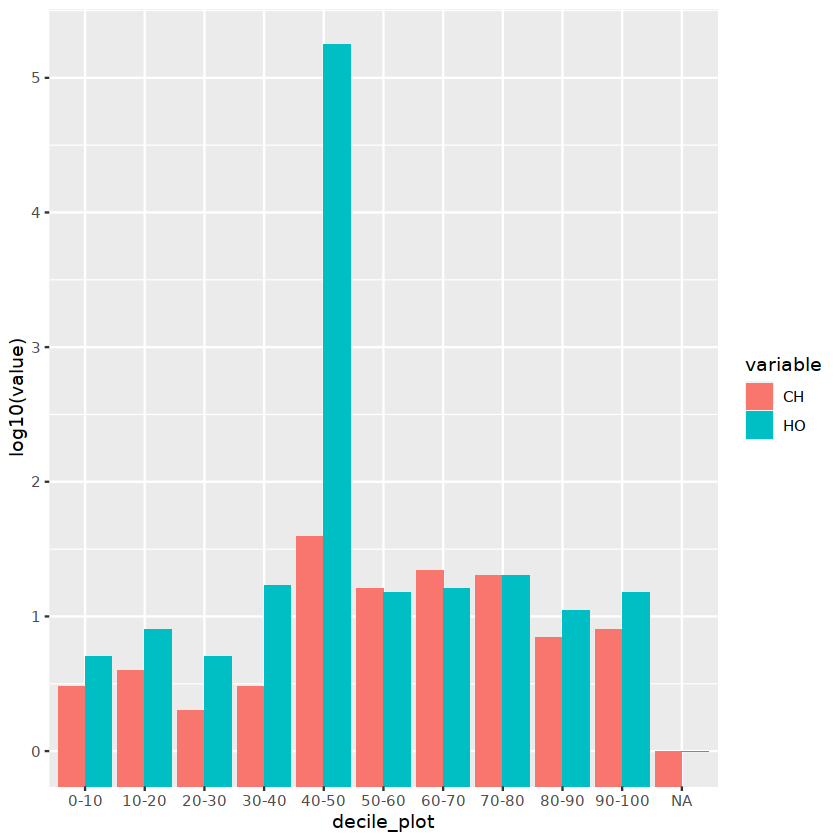

In [55]:
ggplot(melted[!melted$variable %in% 'HE',], aes(x=decile_plot, y=log10(value), fill=variable)) + 
    geom_bar(stat='identity', position = 'dodge')

In [70]:
get_loeuf_data <- function(files, maf, mutation){
    
    dt = load_knockout_bundle(files, maf, mutation)

    # translate genes into hgnc_symbol
    hgnc_bridge <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/hgnc/211026_hgnc_ensgid_link.csv')
    colnames(hgnc_bridge)[2] <- 'gene_id'
    dt <- merge(dt, hgnc_bridge, by = 'gene_id', all.x = TRUE)
    
    # Load LOEUF deciles
    constraints <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv')
    constraints$loeuf <- constraints$oe_lof_upper 
    constraints <- constraints[constraints$canonical == TRUE,]

    # create deciles
    deciles_loeuf_seq <- seq(0,1,by = 0.1)
    deciles_loeuf <- quantile(constraints$loeuf, probs = deciles_loeuf_seq, na.rm = T)
    constraints$decile <- cut(constraints$loeuf, deciles_loeuf)
    levels(constraints$decile) <- deciles_loeuf_seq*100
    constraints$decile_plot <-  paste0(constraints$decile,'-', as.numeric(as.character(constraints$decile))+10)
    constraints$decile_plot[constraints$decile_plot == 'NA-NA'] <- NA
    
    colnames(constraints)[1] <- 'hgnc_symbol'
    combined <- merge(dt, constraints[,c('hgnc_symbol','decile_plot')], by = 'hgnc_symbol')
    combined <- combined[combined$CH > 0 | combined$HO > 0]
    melted <- melt(combined)
    return(melted)
    
}

In [81]:

combi <- do.call(rbind, lapply(c('ptv','ptv_ptv_LC','ptv_damaging_missense'), function(mut){
    d <- get_loeuf_data(knockouts, '01_50', mut)
    d$mut <- mut
    return(d)
}))


Warning message in melt.data.table(combined):
"id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns [hgnc_symbol, gene_id, decile_plot, ...]. Consider providing at least one of 'id' or 'measure' vars in future."
Warning message in melt.data.table(combined):
"id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns [hgnc_symbol, gene_id, decile_plot, ...]. Consider providing at least one of 'id' or 'measure' vars in future."
Warning message in melt.data.table(combined):
"id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns [hgnc_symbol, gene_id, decile_plot, ...]. Consider providing at least one of 'id' or 'measure' vars in future."


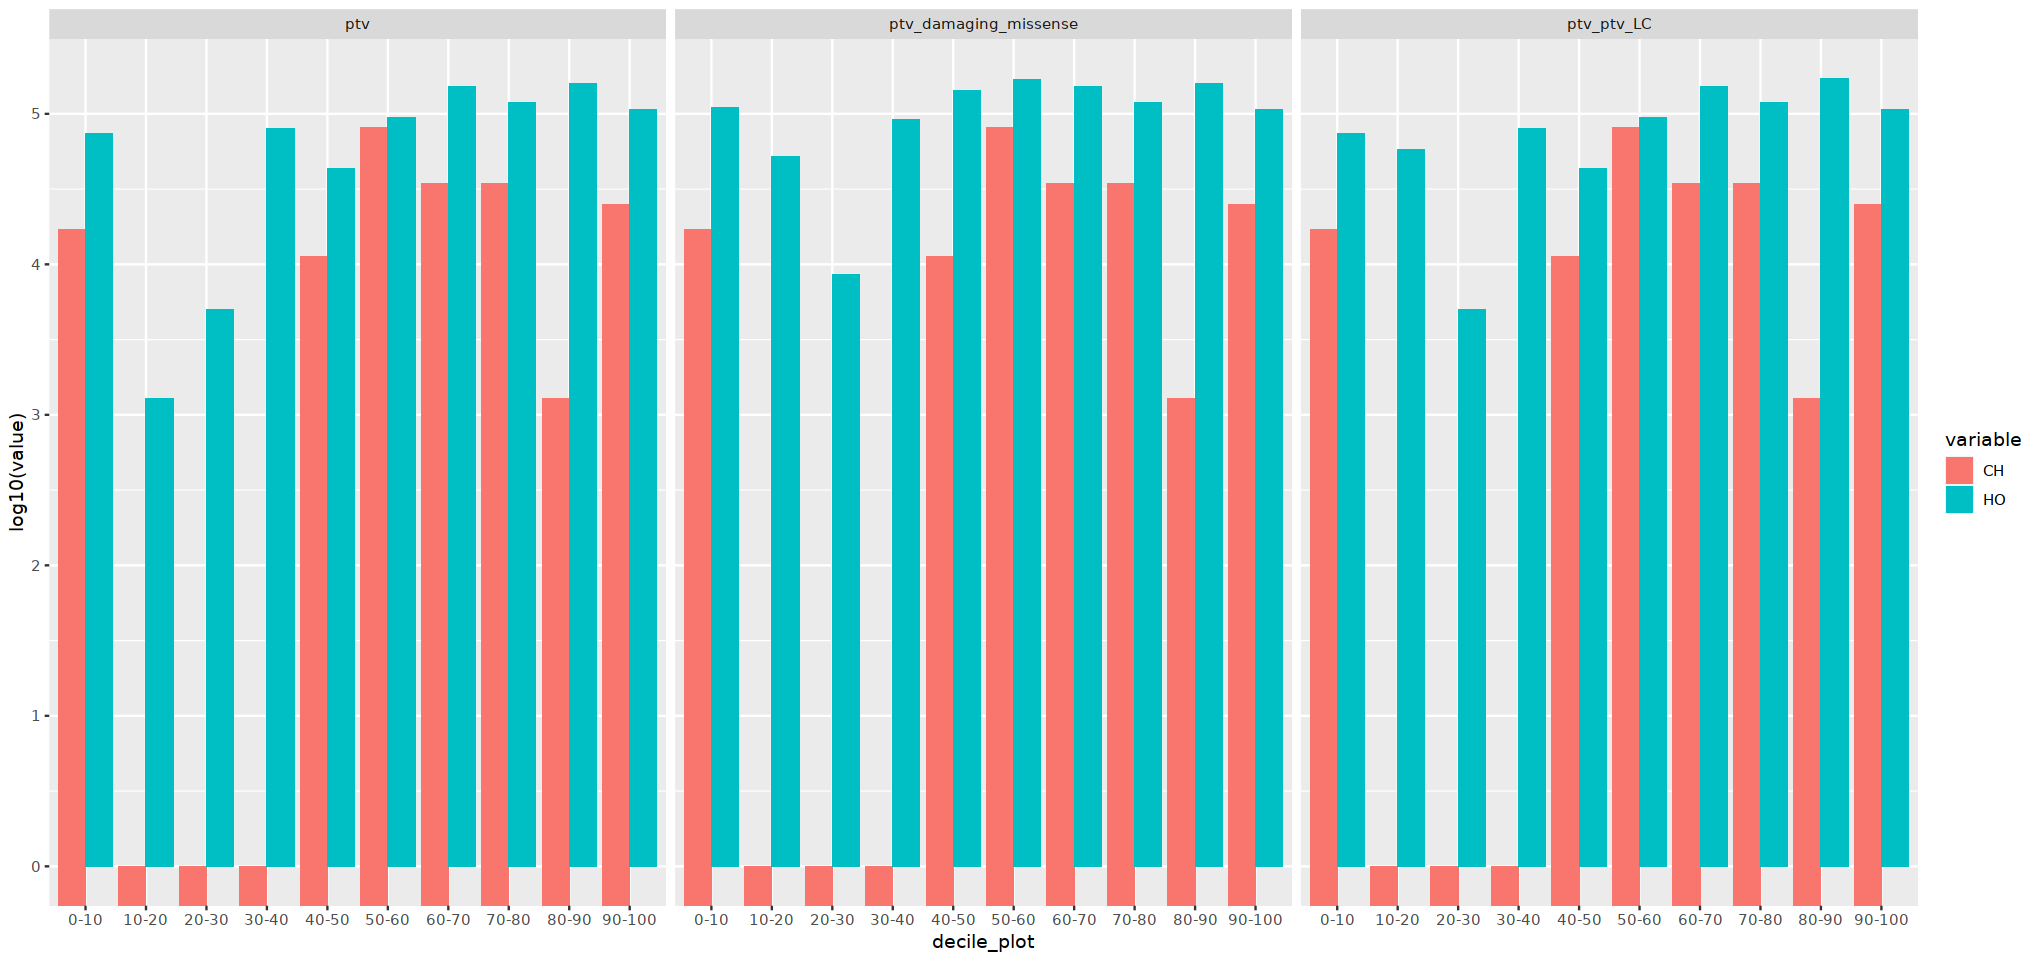

In [82]:
options(repr.plot.width=17, repr.plot.height=8)
ggplot(combi[!combi$variable %in% 'HE' & !is.na(combi$decile_plot),], aes(x=decile_plot, y=log10(value), fill=variable)) + 
    geom_bar(stat='identity', position = 'dodge') +
    facet_wrap(~mut)